In [14]:
!pip install -Uq pymcel

In [15]:
!pip install -Uq numpy

In [16]:
import pymcel as pc

import numpy as np

In [22]:
import matplotlib.pyplot as plt

In [28]:
sistema=[
    dict(m=1,r=np.array([0,0,0]),v=np.array([0,0,0])),
    dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,1,0])),
]

In [29]:
K=0.5*sistema[0]['m']*np.linalg.norm(sistema[0]['v'])**2+0.5*sistema[1]['m']*np.linalg.norm(sistema[1]['v'])**2
K

np.float64(0.005)

In [37]:
G=1
U=-G*sistema[0]['m']*sistema[1]['m']/np.linalg.norm(sistema[0]['r']-sistema[1]['r'])
U

np.float64(-0.01)

In [38]:
E=K+U
E

np.float64(-0.005)

In [39]:
ts=np.linspace(0,10,100)
rs,vs,rps,vps,cuadraturas= pc.ncuerpos_solucion(sistema,ts)

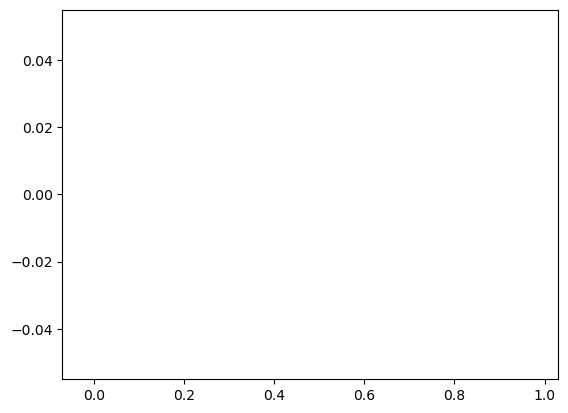

In [61]:
plt.plot(rps[0,:,0],rps[0,:,1],label='Cuerpo 1')
plt.plot(rps[1,:,0],rps[1,:,1],label='Cuerpo 2')


In [40]:
!pip install -Uq rebound

In [43]:
import rebound as rb

In [44]:
sim=rb.Simulation()

In [45]:
sim.G

1.0

In [ ]:
sim.add(m=0.01)

In [47]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	1
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x72484e326450, m=1.0 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
---------------------------------
The following fields have non-default values:
N:
< 0
---
> 1
rand_seed:
< 150270
---
> 91018
particles:
> (128 bytes, values not printed)



In [52]:

sim.add(m=0.01,x=1,vy=1)

In [62]:
ts=np.linspace(0,10,100)
rs=np.zeros((2,100,3))
vs=np.zeros((2,100,3))
rps=np.zeros((2,100,3))
vps=np.zeros((2,100,3))

for i, t in enumerate(ts):
    sim.integrate(t)
    rs[0,i]=sim.particles[0].xyz
    vs[0,i]=sim.particles[0].vxyz
    rs[1,i]=sim.particles[1].xyz
    vs[1,i]=sim.particles[1].vxyz
    sim.move_to_com()
    rps[0,i]=sim.particles[0].xyz
    vps[0,i]=sim.particles[0].vxyz
    rps[1,i]=sim.particles[1].xyz
    vps[1,i]=sim.particles[1].vxyz